# Практическая работа №4. Полиномиальная регрессия в задачах АПК

Цель работы: разобраться, как работает полиномиальная регрессия, сравнить её с обычной линейной регрессией и посмотреть, почему слишком большая степень полинома может давать переобучение.

В примере рассматривается зависимость урожайности от дозы удобрения. Это нормальный пример для АПК, потому что урожайность не всегда растет просто по прямой. Часто сначала удобрение помогает, потом эффект становится меньше, а при слишком большой дозе результат может даже ухудшаться.


## 1. Подготовка окружения

Сначала импортируем библиотеки.

`numpy` нужен для работы с числами и массивами.  
`matplotlib` нужен для построения графиков.  
`LinearRegression` — обычная линейная регрессия.  
`PolynomialFeatures` добавляет степени признака, например x² и x³.  
`train_test_split` делит данные на обучающую и тестовую выборки.  
`mean_squared_error` и `r2_score` нужны для оценки качества модели.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Синтетический пример: урожайность и доза удобрения

Сгенерируем данные. X — это доза удобрения в кг/га, а y — урожайность в ц/га. Истинная зависимость специально сделана квадратичной, потому что в реальности урожайность часто растет не бесконечно, а имеет максимум.


In [2]:
rng = np.random.default_rng(42)

X = np.linspace(0, 200, 40).reshape(-1, 1)  # доза удобрения, кг/га
y_true = -0.005 * X**2 + 1.2 * X + 20       # идеальная зависимость
noise = rng.normal(0, 10, size=X.shape)     # случайный шум
y = (y_true + noise).ravel()                # наблюдаемая урожайность

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (40, 1)
Размер y: (40,)


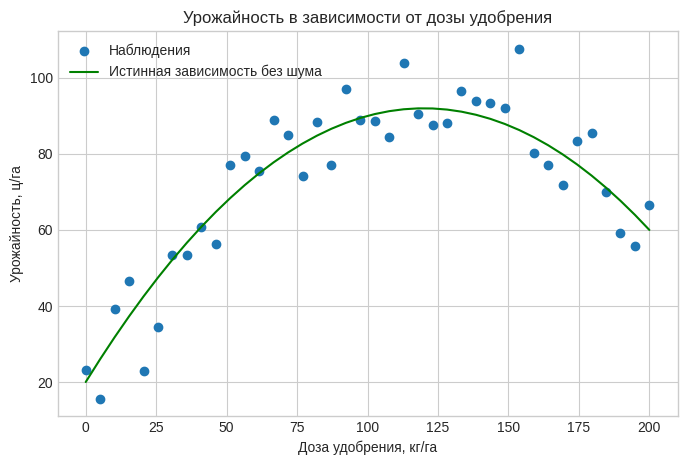

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Наблюдения")
plt.plot(X, y_true, color="green", label="Истинная зависимость без шума")
plt.xlabel("Доза удобрения, кг/га")
plt.ylabel("Урожайность, ц/га")
plt.title("Урожайность в зависимости от дозы удобрения")
plt.legend()
plt.show()

По графику видно, что зависимость не похожа на прямую линию. Урожайность сначала растет, потом достигает максимума, а после слишком большой дозы удобрения начинает снижаться.

Если смотреть на исходную формулу без шума, максимум находится примерно при дозе 120 кг/га. Урожайность в этой точке около 92.0 ц/га. Это похоже на реальную ситуацию: удобрение полезно до определенного момента, но слишком большая доза уже не дает пользы.


## 3. Разделение данных

Делим данные на обучающую и тестовую выборки. На обучающей модель учится, а на тестовой мы проверяем, как она работает на новых данных. Это нужно, чтобы не оценивать модель только по тем данным, которые она уже видела.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (30, 1)
Тестовая выборка: (10, 1)


## 4. Линейная регрессия

Для начала обучим обычную линейную регрессию. Это будет базовая модель, с которой потом сравним полиномиальные модели.


In [5]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Линейная модель:")
print("w0 (intercept) =", lin_model.intercept_)
print("w1 (slope) =", lin_model.coef_[0])

Линейная модель:
w0 (intercept) = 49.23386068001628
w1 (slope) = 0.2416976173230693


Коэффициент наклона w1 получился примерно 0.242. Если говорить простыми словами, линейная модель считает, что при увеличении дозы удобрения на 1 кг/га урожайность в среднем меняется примерно на это число.

Но проблема в том, что здесь реальная зависимость не линейная. Поэтому один наклон для всей кривой не очень хорошо описывает ситуацию.


In [6]:
y_pred_lin = lin_model.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("MSE линейной модели =", mse_lin)
print("R^2 линейной модели =", r2_lin)

MSE линейной модели = 439.17952440038516
R^2 линейной модели = 0.043556785344083804


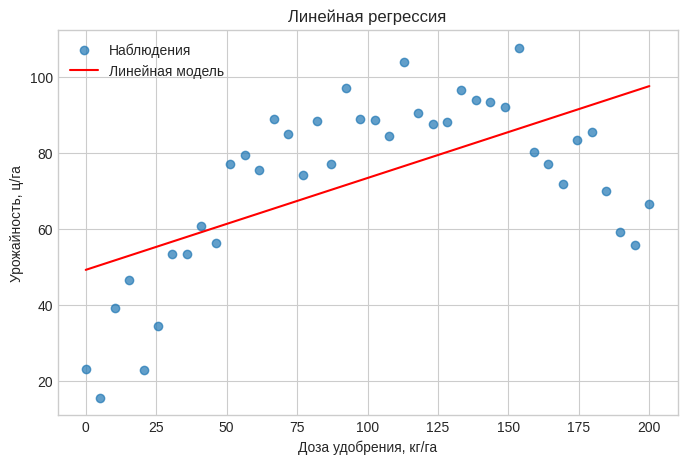

In [7]:
X_line = np.linspace(0, 200, 200).reshape(-1, 1)
y_line_lin = lin_model.predict(X_line)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="Наблюдения")
plt.plot(X_line, y_line_lin, color="red", label="Линейная модель")
plt.xlabel("Доза удобрения, кг/га")
plt.ylabel("Урожайность, ц/га")
plt.title("Линейная регрессия")
plt.legend()
plt.show()

Линейная модель даёт систематические ошибки. Она не может нормально поймать изгиб: в начале и в конце графика она описывает данные хуже, потому что пытается провести одну прямую через зависимость, которая на самом деле похожа на параболу.


## 5. Полиномиальная регрессия степени 2

Теперь добавим признак x². Сама модель LinearRegression остается линейной по коэффициентам, но из-за нового признака она может строить кривую.


In [8]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)

y_pred_poly2 = model_poly2.predict(X_test_poly2)

mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Полиномиальная регрессия степени 2:")
print("MSE =", mse_poly2)
print("R^2 =", r2_poly2)
print("Коэффициенты:", model_poly2.coef_)
print("intercept =", model_poly2.intercept_)

Полиномиальная регрессия степени 2:
MSE = 64.08001125906866
R^2 = 0.8604468365243368
Коэффициенты: [ 1.25914585 -0.00528637]
intercept = 19.003645325404868


## 6. Полиномиальная регрессия степени 3

Теперь проверим степень 3. Она ещё гибче, потому что добавляется x³.


In [9]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)

y_pred_poly3 = model_poly3.predict(X_test_poly3)

mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print("Полиномиальная регрессия степени 3:")
print("MSE =", mse_poly3)
print("R^2 =", r2_poly3)
print("Коэффициенты:", model_poly3.coef_)
print("intercept =", model_poly3.intercept_)

Полиномиальная регрессия степени 3:
MSE = 63.720624503169894
R^2 = 0.8612295074026887
Коэффициенты: [ 1.17300363e+00 -4.14167239e-03 -3.96290686e-06]
intercept = 20.194569342929775


## 7. Сравнение моделей на графике

Построим сразу три модели: линейную, степень 2 и степень 3.


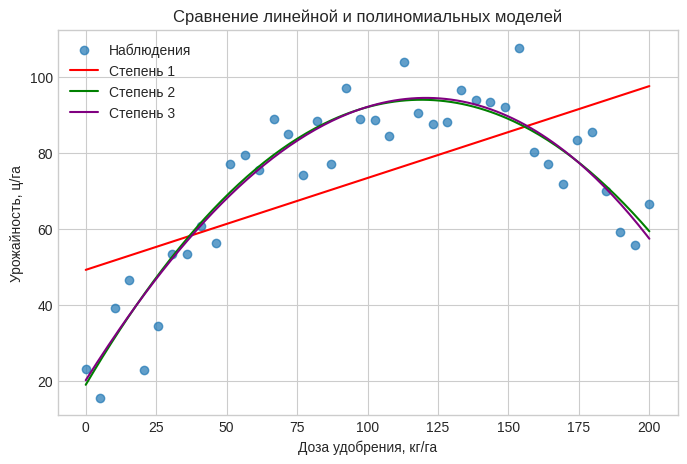

In [10]:
X_line_poly2 = poly2.transform(X_line)
y_line_poly2 = model_poly2.predict(X_line_poly2)

X_line_poly3 = poly3.transform(X_line)
y_line_poly3 = model_poly3.predict(X_line_poly3)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="Наблюдения")
plt.plot(X_line, y_line_lin, color="red", label="Степень 1")
plt.plot(X_line, y_line_poly2, color="green", label="Степень 2")
plt.plot(X_line, y_line_poly3, color="purple", label="Степень 3")
plt.xlabel("Доза удобрения, кг/га")
plt.ylabel("Урожайность, ц/га")
plt.title("Сравнение линейной и полиномиальных моделей")
plt.legend()
plt.show()

In [11]:
results = {
    "Модель": ["Линейная", "Полином степени 2", "Полином степени 3"],
    "MSE": [mse_lin, mse_poly2, mse_poly3],
    "R2": [r2_lin, r2_poly2, r2_poly3]
}

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,Модель,MSE,R2
0,Линейная,439.179524,0.043557
1,Полином степени 2,64.080011,0.860447
2,Полином степени 3,63.720625,0.861230


По метрикам видно, что полиномиальные модели лучше линейной. У линейной модели MSE примерно 439.18, а R² примерно 0.044. У степени 2 MSE примерно 64.08, R² примерно 0.860. У степени 3 MSE примерно 63.72, R² примерно 0.861.

Лучше всего по тестовой ошибке здесь получилась степень 2. Это логично, потому что исходная зависимость как раз была квадратичной. Степень 3 тоже работает неплохо, но сильного смысла усложнять модель нет.


## 8. Исследование степени полинома

Теперь проверим степени от 1 до 6. Это нужно, чтобы посмотреть, как меняется качество и где может начаться переобучение.


In [12]:
degrees = range(1, 7)

train_mse_list = []
test_mse_list = []
train_r2_list = []
test_r2_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse_list.append(mean_squared_error(y_train, y_train_pred))
    test_mse_list.append(mean_squared_error(y_test, y_test_pred))
    train_r2_list.append(r2_score(y_train, y_train_pred))
    test_r2_list.append(r2_score(y_test, y_test_pred))

degree_results = pd.DataFrame({
    "degree": list(degrees),
    "train_MSE": train_mse_list,
    "test_MSE": test_mse_list,
    "train_R2": train_r2_list,
    "test_R2": test_r2_list
})

degree_results

,degree,train_MSE,test_MSE,train_R2,test_R2
0,1,316.340928,439.179524,0.394950,0.043557
1,2,66.151886,64.080011,0.873475,0.860447
2,3,65.785245,63.720625,0.874176,0.861230
3,4,65.112983,71.481836,0.875462,0.844327
4,5,61.792847,93.360010,0.881812,0.796681
5,6,61.788536,91.404836,0.881820,0.800939


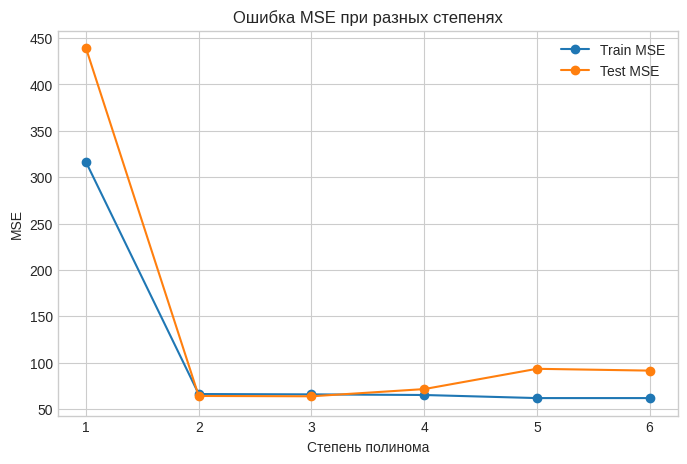

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(degree_results["degree"], degree_results["train_MSE"], marker="o", label="Train MSE")
plt.plot(degree_results["degree"], degree_results["test_MSE"], marker="o", label="Test MSE")
plt.xlabel("Степень полинома")
plt.ylabel("MSE")
plt.title("Ошибка MSE при разных степенях")
plt.legend()
plt.show()

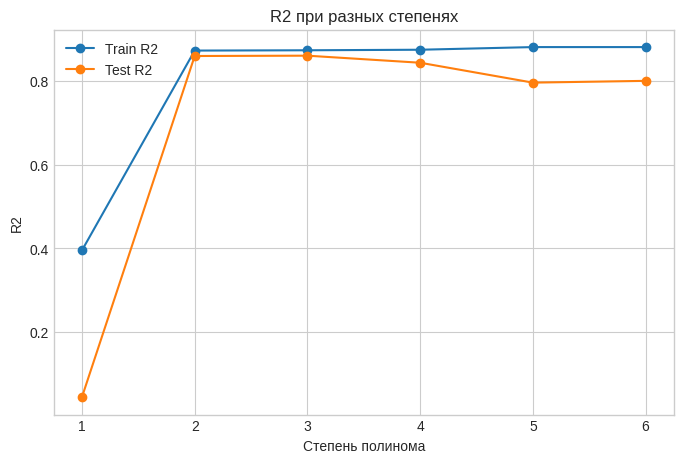

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(degree_results["degree"], degree_results["train_R2"], marker="o", label="Train R2")
plt.plot(degree_results["degree"], degree_results["test_R2"], marker="o", label="Test R2")
plt.xlabel("Степень полинома")
plt.ylabel("R2")
plt.title("R2 при разных степенях")
plt.legend()
plt.show()

По таблице и графикам видно, что минимальная тестовая ошибка получилась при степени 3. При увеличении степени модель может лучше подгоняться под обучающую выборку, но это не всегда значит, что она лучше работает на тесте.

В этой задаче высокая степень не нужна, потому что реальная зависимость простая и похожа на параболу. Если брать слишком большую степень, модель может начать ловить шум, а не нормальную закономерность.


## 9. Мини-кейс на этих же аграрных данных

Как небольшой прикладной вывод можно использовать тот же пример с удобрениями. Фактор — доза удобрения, отклик — урожайность. На графике видно, что зависимость имеет максимум. Значит, в такой задаче полиномиальная регрессия подходит лучше, чем простая линейная модель.

Практический смысл такой: по модели можно примерно понять, что увеличение дозы удобрения полезно не всегда. До определенного значения урожайность растет, но потом избыток удобрения может ухудшать результат или просто быть экономически невыгодным.


## 10. Контрольные вопросы

1. Почему полиномиальная регрессия относится к линейным моделям, хотя график зависимости y(x) может быть кривой?

Потому что модель линейна по коэффициентам. То есть коэффициенты просто умножаются на признаки x, x², x³ и так далее. График может быть кривой из-за степеней x, но сама регрессия всё равно ищет коэффициенты линейным способом.

2. В чём состоит роль класса PolynomialFeatures в scikit-learn?

Он создает новые признаки из исходного признака. Например, если был x, то он может добавить x² и x³. После этого обычная линейная регрессия уже может строить нелинейную кривую.

3. Какие плюсы и минусы полиномиальной регрессии по сравнению с простой линейной?

Плюс в том, что она может описывать криволинейные зависимости. Например, когда сначала показатель растет, а потом падает. Минус в том, что при большой степени модель может переобучиться и начать повторять случайный шум.

4. Почему рост степени полинома может приводить к переобучению? Как это проявляется в ошибках на train/test?

Чем выше степень, тем гибче кривая. Она может слишком хорошо подстроиться под обучающие точки. Тогда ошибка на train уменьшается, а на test может не улучшаться или даже расти. Это и есть признак переобучения.

5. Приведите пример аграрной задачи, где полиномиальная регрессия более уместна, чем линейная.

Например, зависимость урожайности от дозы удобрения. Маленькая доза дает слабый эффект, средняя доза может дать максимум урожайности, а слишком большая доза уже не улучшает результат. Поэтому такая зависимость лучше описывается кривой, а не прямой.


## Вывод

В этой работе я сравнил линейную регрессию и полиномиальные модели. Линейная модель оказалась слишком простой, потому что она строит только прямую и плохо описывает зависимость с максимумом.

Полиномиальная регрессия степени 2 подошла лучше всего, потому что исходная зависимость была квадратичной. Степень 3 тоже может описывать кривую, но в данной задаче она не дает явного преимущества. Главный вывод: степень полинома нужно выбирать осторожно, потому что слишком сложная модель может переобучиться.
